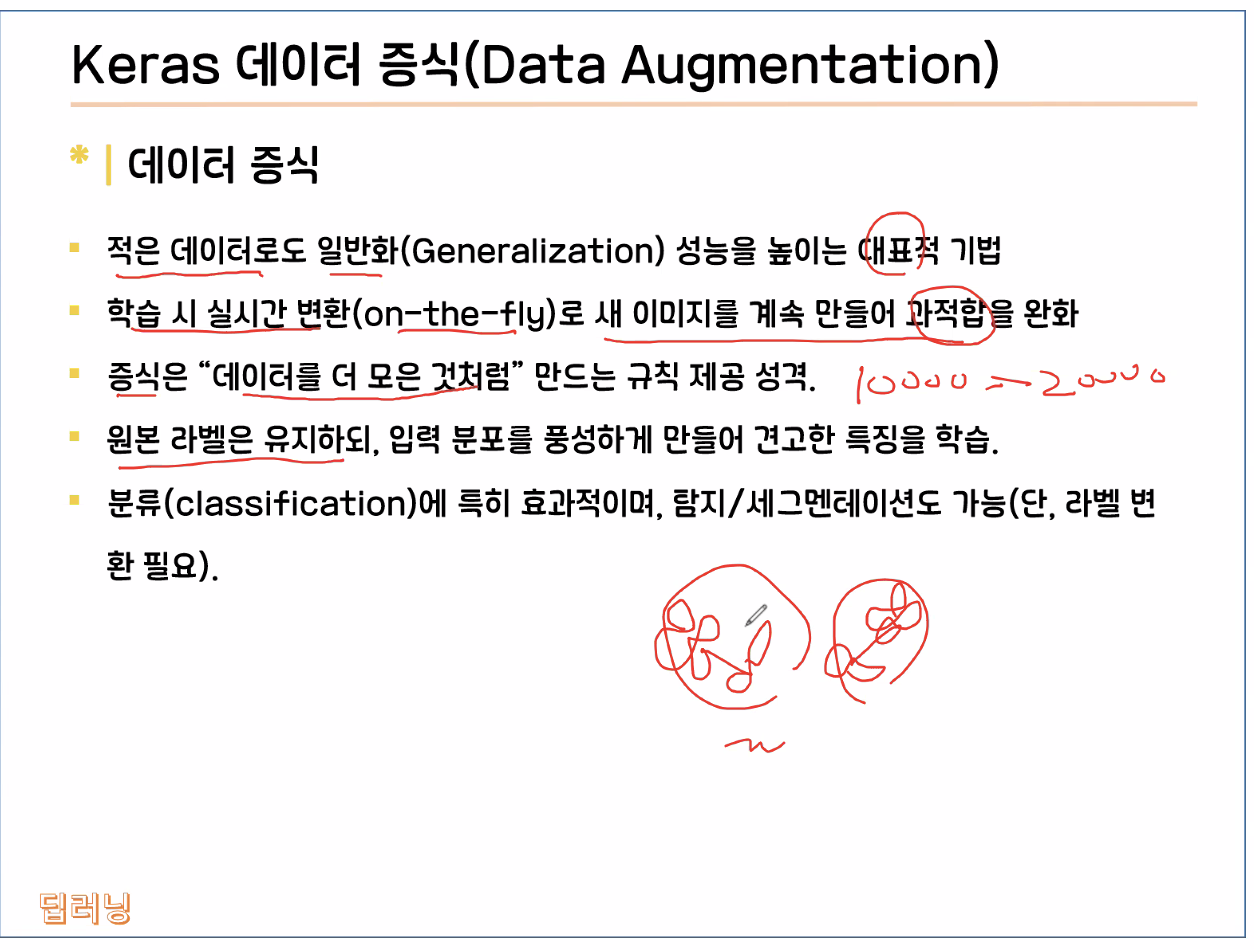

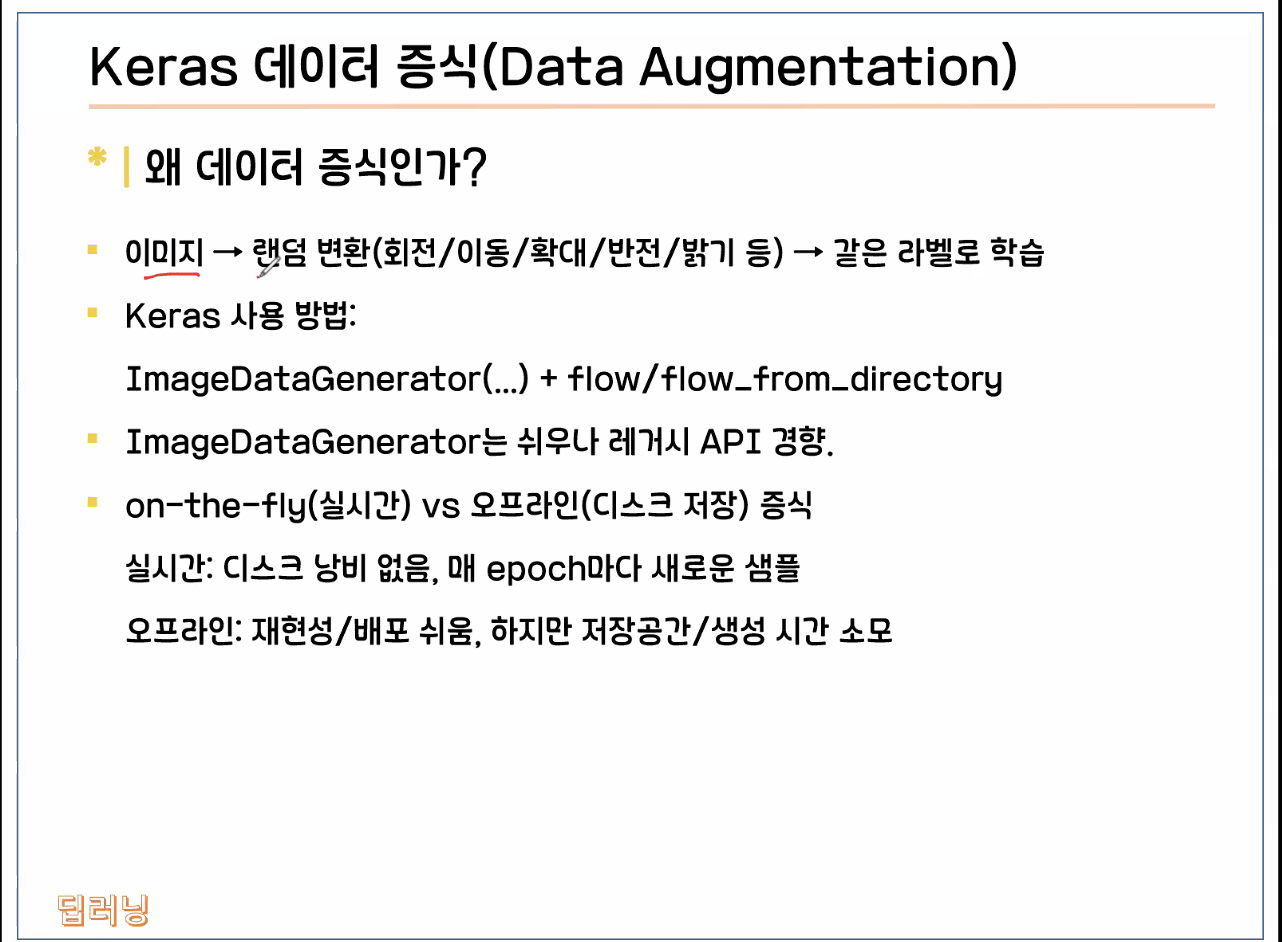

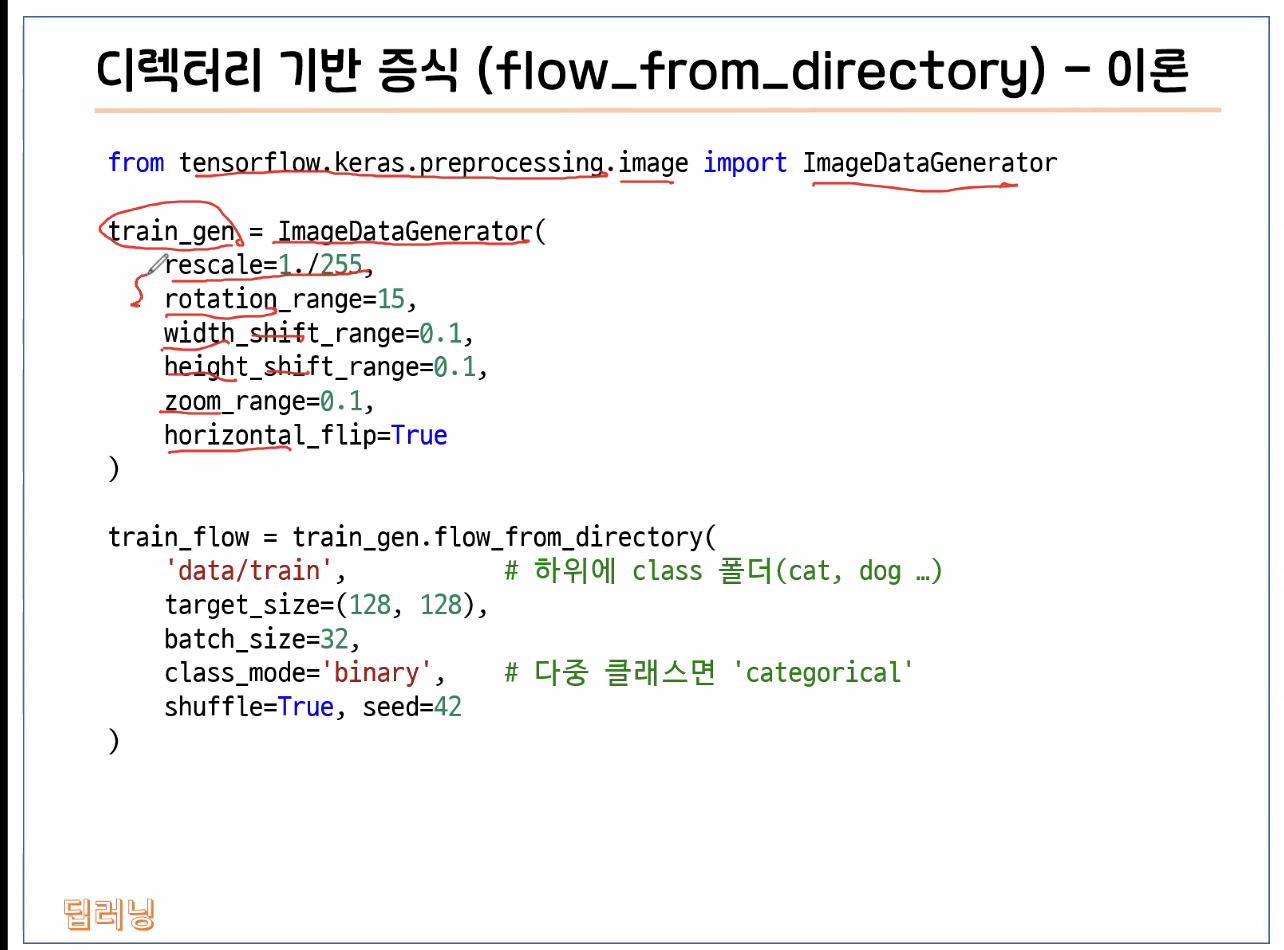

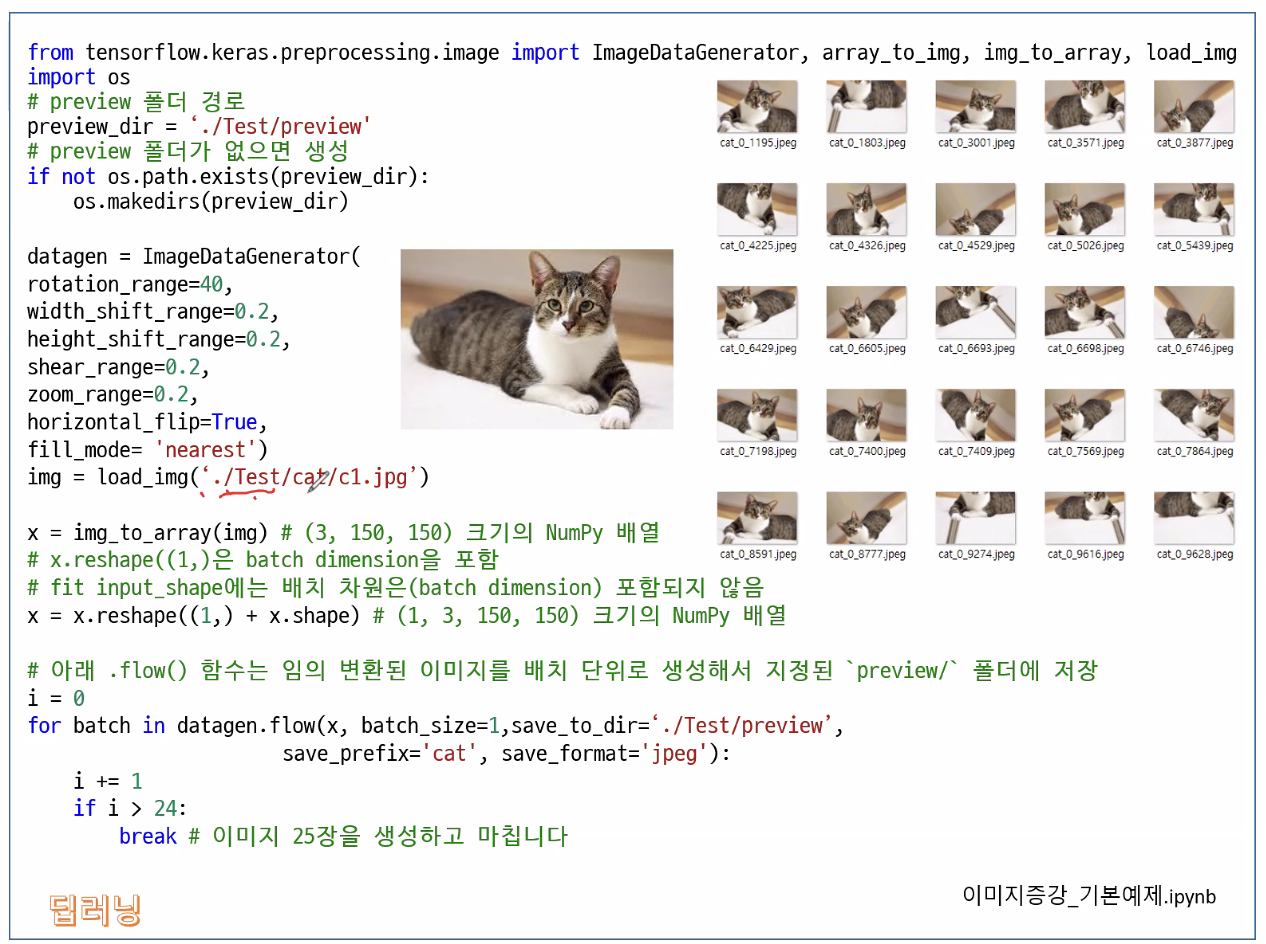

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import array_to_img, img_to_array, load_img
import os

# 디렉터리 기반 데이터 증식 설정
# rescale: 픽셀값을 0~255에서 0~1 범위로 정규화
# rotation_range: 이미지를 최대 15도까지 랜덤 회전
# width_shift_range / height_shift_range: 가로/세로 방향으로 랜덤 이동
# zoom_range: 이미지를 랜덤 확대/축소
# horizontal_flip: 좌우 반전 적용
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

# 폴더 구조가 Train/cat, Train/dog 형태라면 Train을 지정한다.
# 이미지 예시의 'data/train' 구조를 쓰는 경우에는 아래 경로를 'data/train'으로 바꾸면 된다.
train_flow = train_gen.flow_from_directory(
    'Train',              # 하위에 class 폴더(cat, dog 등)가 있어야 함
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',  # 다중 클래스면 'categorical' 사용
    shuffle=True,
    seed=42
)


# preview 폴더 경로
# Test 폴더는 읽기 전용일 수 있으므로, 현재 작업 폴더 아래 preview 폴더에 저장한다.
preview_dir = './preview'

# preview 폴더가 없으면 생성
if not os.path.exists(preview_dir):
    os.makedirs(preview_dir, exist_ok=True)

# 한 장의 이미지를 여러 방식으로 변형해서 저장하기 위한 증식 설정
datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# 원본 이미지 1장을 불러온다.
img = load_img('./Test/cat/c1.jpg')

# 이미지를 NumPy 배열로 변환한다.
x = img_to_array(img)  # (높이, 너비, 채널) 크기의 NumPy 배열

# flow()에 넣기 위해 batch 차원을 추가한다.
# 예: (150, 150, 3) -> (1, 150, 150, 3)
x = x.reshape((1,) + x.shape)

# flow()는 변형 이미지를 batch 단위로 계속 생성한다.
# save_to_dir로 지정한 preview 폴더에 이미지를 저장한다.
i = 0
for batch in datagen.flow(x, batch_size=1,
                          save_to_dir=preview_dir,
                          save_prefix='cat',
                          save_format='jpeg'):
    i += 1
    if i > 24:
        break  # 이미지 25장을 생성하고 마침


Found 2000 images belonging to 2 classes.


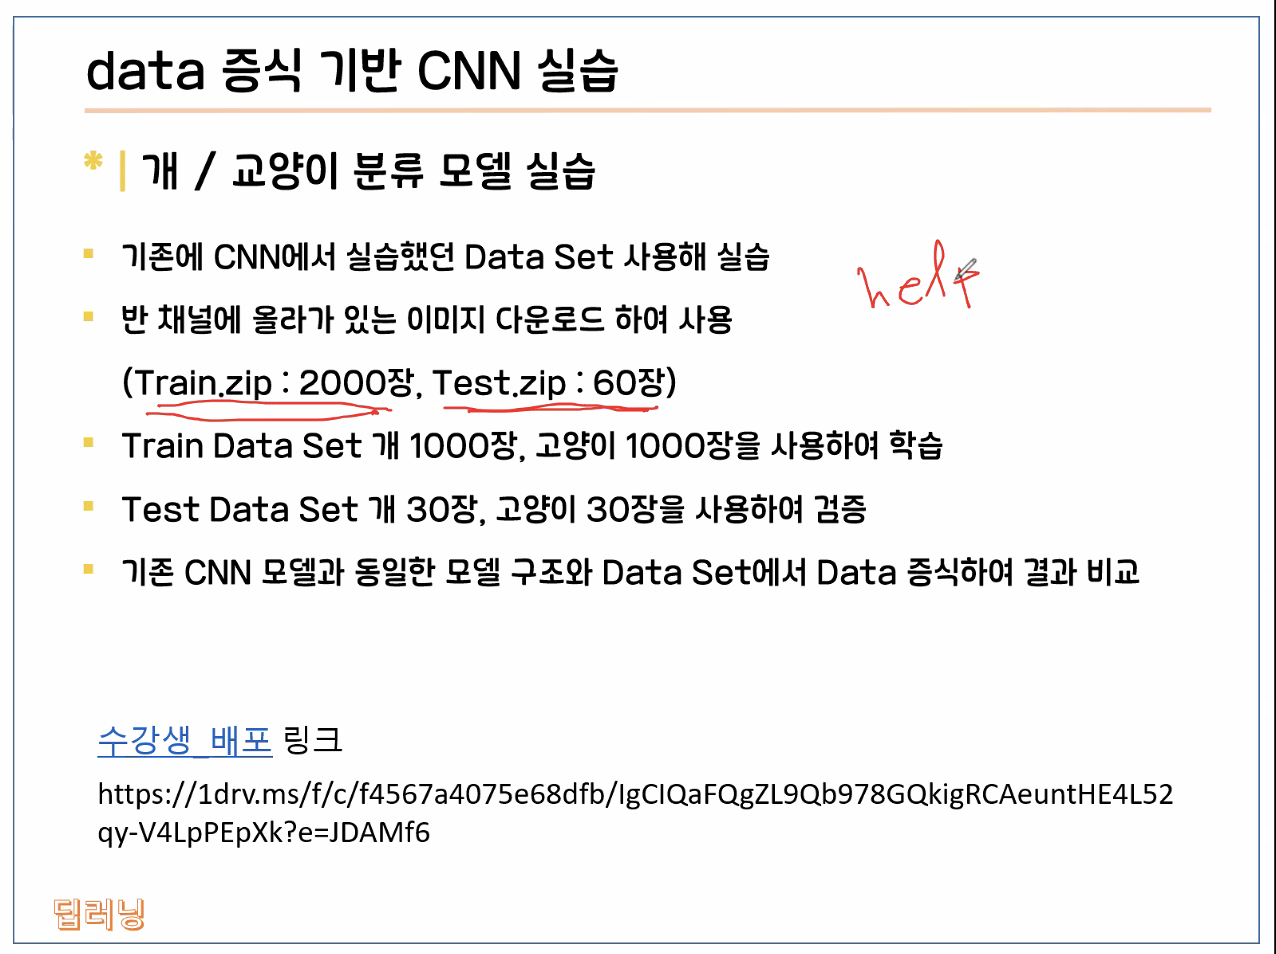